In [26]:
import glob
import os
import h5py
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 # User can set this outside the class if needed

from astropy.io import fits
from astropy.io.votable import parse_single_table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u

import sys 
import gc 

import importlib
sys.path.insert(0, '/home/thomasli/spherex/selfcal')
import LoadExposure
import WCSUtility
import MakeMap
import MapUtility
importlib.reload(MakeMap)

import os
import h5py
from tqdm import tqdm
from multiprocessing import Pool 
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table

from reproject import reproject_interp
from reproject import reproject_exact
from reproject import reproject_adaptive

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr
import sys 
import gc 
from functools import partial

from MapUtility import bit_to_bool, make_weight, find_outliers, map_pixels, det_to_sub
from WCSUtility import load_from_fits, save_to_fits, find_optimal_frame

from datetime import datetime

In [56]:
fit_hdul = fits.open('/home/thomasli/spherex/selfcal/outputs/nep_det2_ch3-4_6p2arcsec.fits')
mosaic = fit_hdul[0].data
wcs = WCS(fit_hdul[0].header, naxis=2)
O = fit_hdul[1].data
D = fit_hdul[2].data


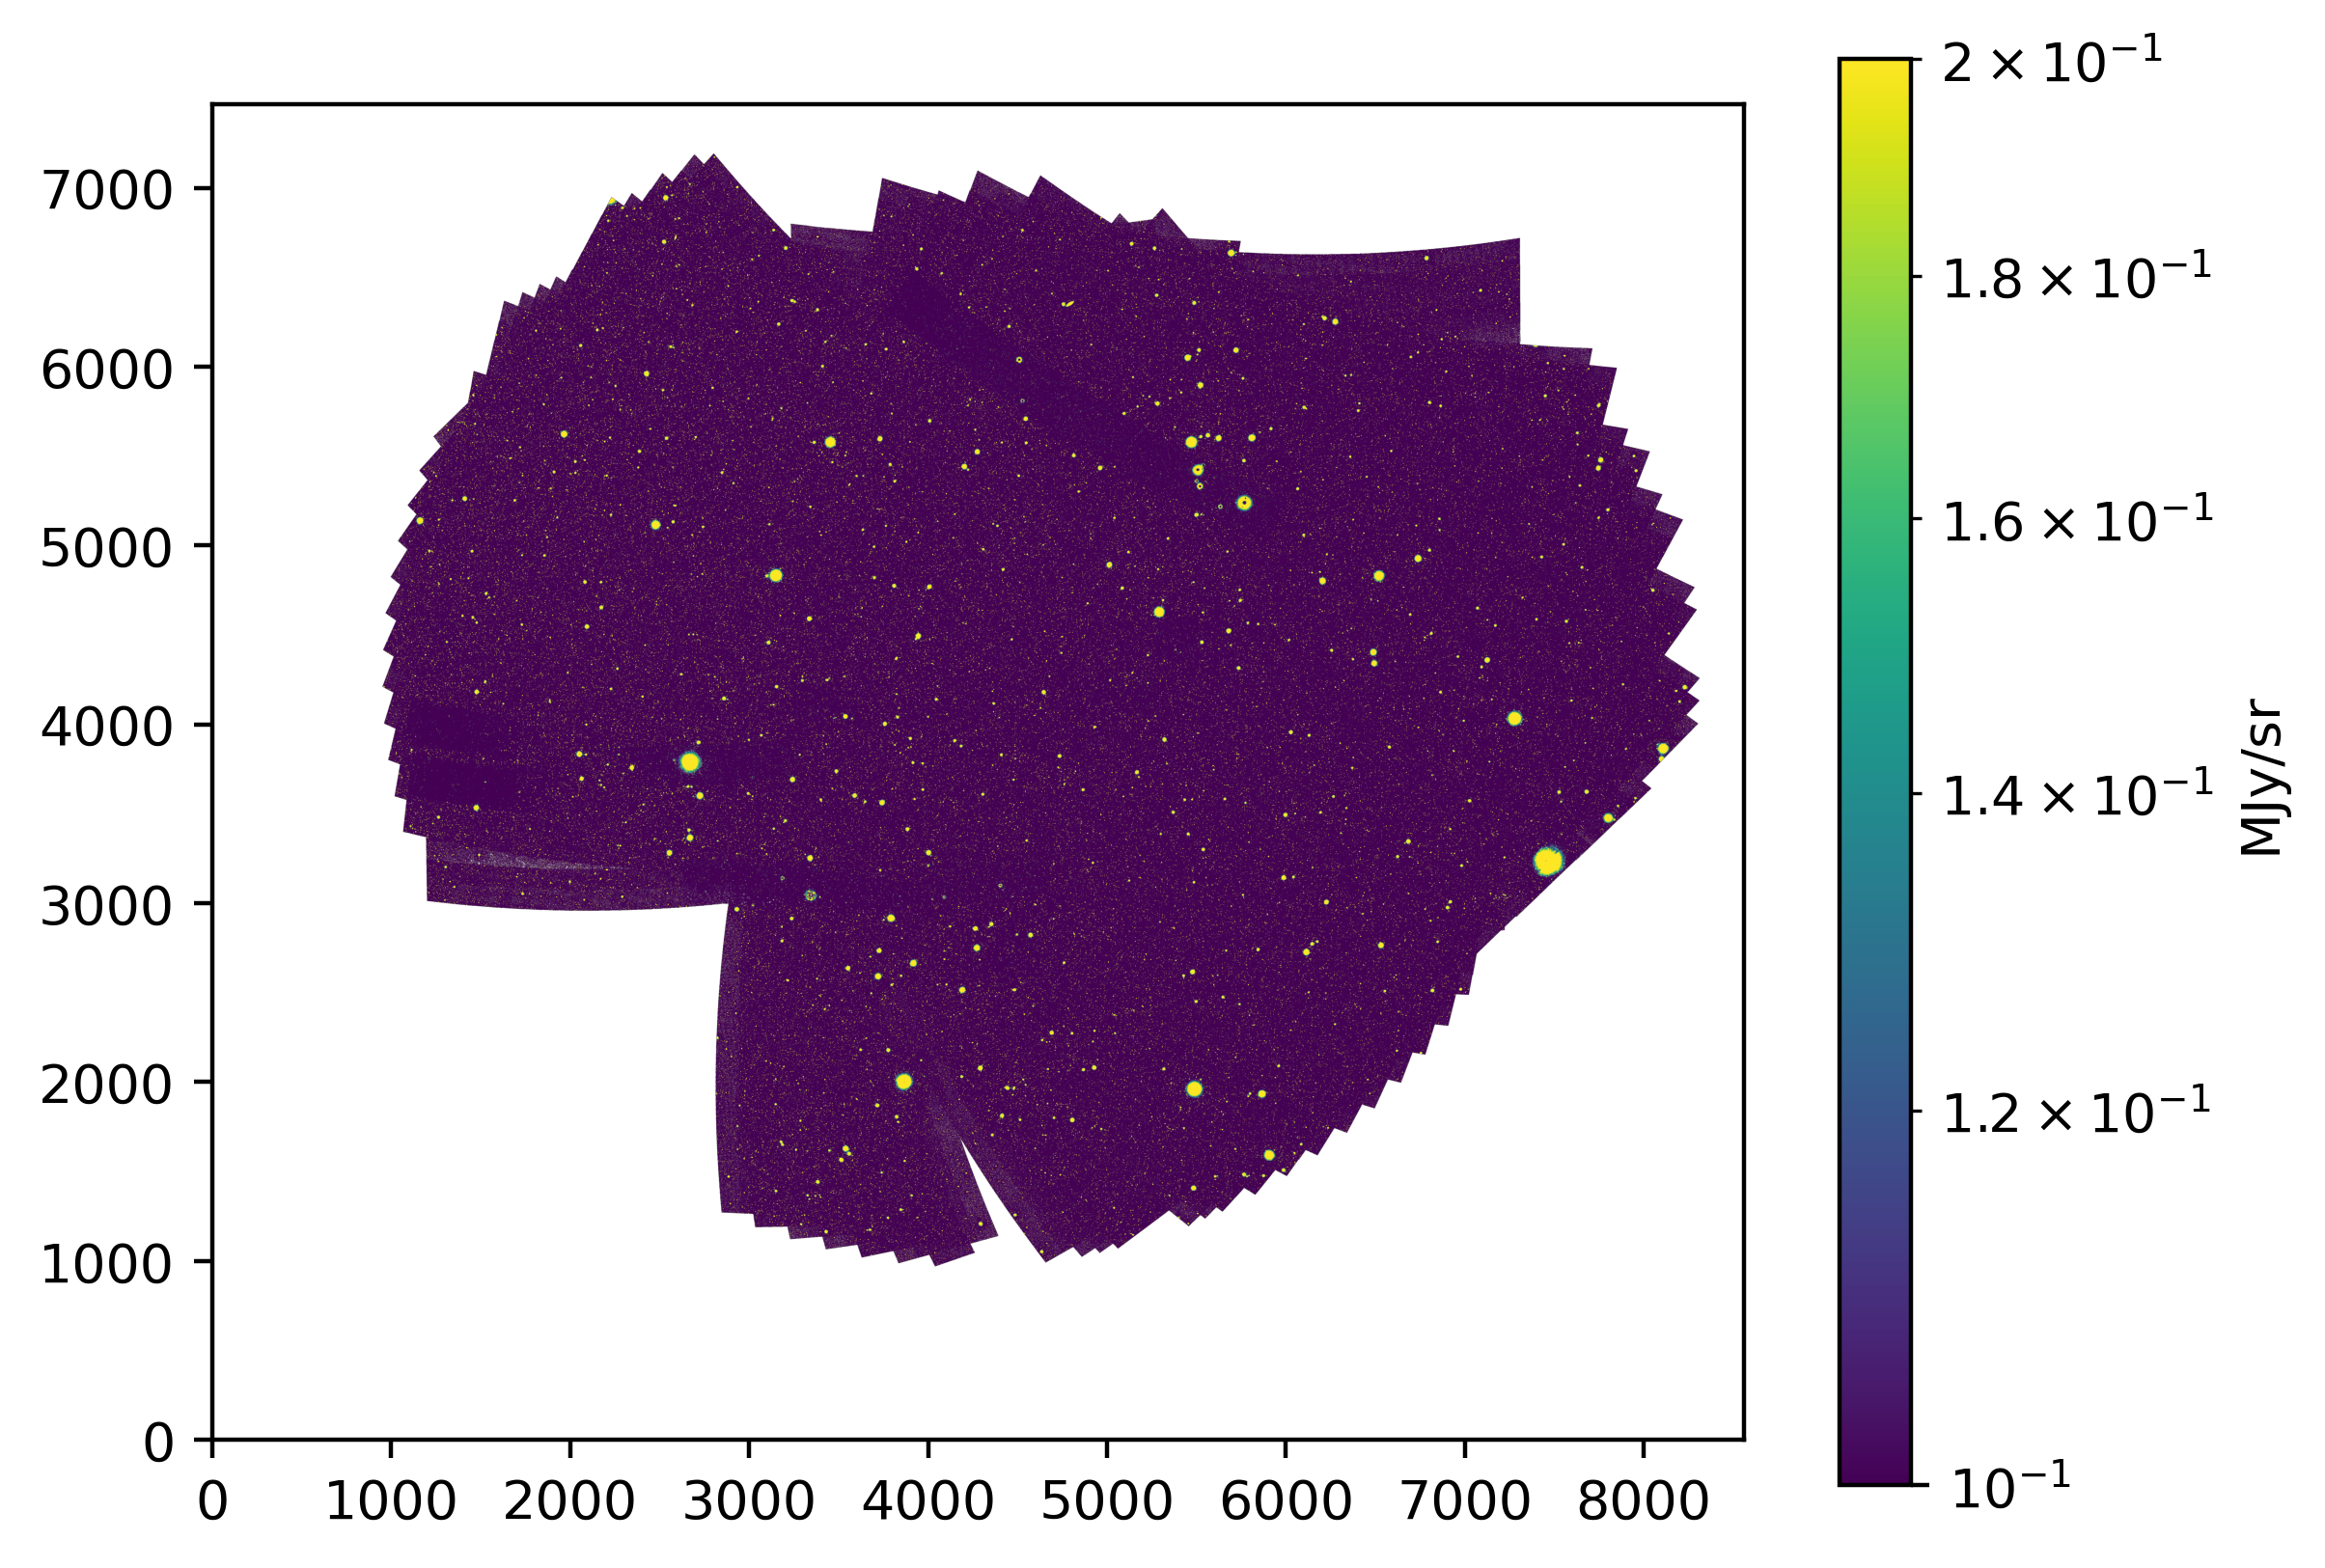

In [57]:
im = plt.imshow(mosaic, origin='lower', norm=LogNorm(vmin=1.e-1, vmax=2e-1))
plt.colorbar(im, label='MJy/sr')

In [33]:
# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection=wcs)
# im = ax.imshow(mosaic, norm=LogNorm(vmin=0.08, vmax=0.15), origin='lower')

# # Explicitly set axis labels
# ax.coords['ra'].set_axislabel('RA')
# ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
# ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
# ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
# ax.coords['dec'].set_axislabel('DEC')

# # Add grid overlay
# ax.grid(color='black', linestyle='--', alpha=0.5)

# # Rescale the colorbar to match the height of the plot
# cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.040, pad=0.04)
# cbar.set_label('MJy/sr')

# # Add title
# ax.set_title("Detector 4 (ch12)", pad=20)
# # plt.savefig('/home/thomasli/spherex/selfcal/figures/det2_mosaic.png', dpi=300, bbox_inches='tight')

In [ ]:
chs_list = [[1,2], [3,4], [5,6], [7,8], [9,10], [11,12], [13,14], [15,16]]

In [3]:
# chs_list = [[1, 2], [3, 4], [5, 6], [7, 8], [9, 10], [11, 12], [13, 14], [15, 16]]

# fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw={'projection': wcs})
# axes = axes.flatten()

# for i, chs in enumerate(chs_list):
#     fit_hdul = fits.open(f'/home/thomasli/spherex/selfcal/outputs/nep_det2_ch{chs[0]}-{chs[1]}_6p2arcsec.fits')
#     mosaic = fit_hdul[0].data
#     wcs = WCS(fit_hdul[0].header, naxis=2)

#     ax = axes[i]
#     im = ax.imshow(mosaic, norm=LogNorm(vmin=0.001, vmax=0.3), origin='lower')

#     # Explicitly set axis labels
#     ax.coords['ra'].set_axislabel('RA')
#     ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
#     ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
#     ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
#     ax.coords['dec'].set_axislabel('DEC')

#     # Add grid overlay
#     ax.grid(color='black', linestyle='--', alpha=0.5)

#     # Add title
#     ax.set_title(f"Detector 2 (ch{chs[0]}-{chs[1]})", pad=20)

# # Adjust layout and add colorbar
# fig.subplots_adjust(right=0.85, hspace=0.1)  # Reduce hspace to make the gap smaller
# cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
# cbar = fig.colorbar(im, cax=cbar_ax)
# cbar.set_label('MJy/sr')

# plt.show()

In [11]:

# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection=wcs)

# # Calculate the zoomed region
# ny, nx = mosaic.shape
# zoomed_extent = (0.4 * nx, 0.6 * nx, 0.5 * ny, 0.7 * ny)
# xmin, xmax, ymin, ymax = zoomed_extent

# im = ax.imshow(mosaic[int(ymin):int(ymax), int(xmin):int(xmax)], 
#                norm=LogNorm(vmin=0.001, vmax=0.3), origin='lower', 
#                extent=[xmin, xmax, ymin, ymax])

# # Explicitly set axis labels
# ax.coords['ra'].set_axislabel('RA')
# ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
# ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
# ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
# ax.coords['dec'].set_axislabel('DEC')

# # Add grid overlay
# ax.grid(color='black', linestyle='--', alpha=0.5)

# # Rescale the colorbar to match the height of the plot
# cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.040, pad=0.04)
# cbar.set_label('MJy/sr')

# # Add title
# ax.set_title("Detector 2 (ch3-4) - Zoomed to Center 20%", pad=20)

In [17]:
reproj_list = sorted(glob.glob('/home/thomasli/spherex/selfcal/nep_det2_6p2arcsec/*.h5'))
ref_shape = mosaic.shape
reproj_list = sorted(glob.glob('/home/thomasli/spherex/selfcal/nep_det2_6p2arcsec/*.h5'))

det_idx_list = []
exp_idx_list = []
for file in tqdm(reproj_list):
    file_name = os.path.basename(file)
    det_idx_list.append(int(file_name[file_name.find('det_')+4:file_name.find('det_')+6]))
    exp_idx_list.append(int(file_name[file_name.find('exp_')+4:file_name.find('exp_')+8]))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1837/1837 [00:00<00:00, 1189767.83it/s]


In [18]:
from scipy.ndimage import gaussian_filter, median_filter
from skimage import measure
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import make_smoothing_spline

def interpolate_array(data_arr, interp_factor=5):
    interp_arr = np.hstack([
        np.linspace(data_arr[i], data_arr[i + 1], interp_factor, endpoint=False) 
        for i in range(len(data_arr) - 1)
    ] + [data_arr[-1]])  # Append the last element
    return interp_arr

def make_chunk_map(band):
    hdul = fits.open('/data1/SPHEREx/Data/Survey_3/calibs/SSDC_SpecCal_v2025Feb/SSDC_CENTER_all_v20250202.fits')
    wav_map = hdul[0].data[band-1]
    tbl = Table.read('/home/thomasli/spherex/spherex_nep_catalogues/spherex_channels.csv')
    sub_tbl = tbl[tbl['band'] == band]
    channel_edges = np.hstack([sub_tbl['lmin'].data, sub_tbl['lmax'].data[-1:]])
    fine_edges = interpolate_array(channel_edges, interp_factor=5)
    channel_idx = np.searchsorted(fine_edges, wav_map, side='right')

    mask_smooth = np.zeros_like(channel_idx)

    for i in tqdm(np.unique(channel_idx)[:]):
        mask = channel_idx >= i
        contours = measure.find_contours(mask, level=0.1, positive_orientation='low')
        if len(contours) == 0:
            continue
        contour = []
        for c in contours:
            if len(c) > 500:  # Filter out small contours
                contour.append(c)
        contour = np.concatenate(contour)
        ys, xs = contour[:, 0], contour[:, 1]

        # sort
        sorted_indices = np.argsort(xs)
        xs = xs[sorted_indices]
        ys = ys[sorted_indices]
        # remove duplicates
        unique_indices = np.unique(xs, return_index=True)[1]
        xs = xs[unique_indices]
        ys = ys[unique_indices]

        spl = make_smoothing_spline(xs, ys, lam=1e7)
        x_idx = np.arange(mask_smooth.shape[1])
        y_lim = spl(x_idx)
        y_lim = np.clip(y_lim, 0, mask_smooth.shape[0]-1)

        for x, y in zip(x_idx, y_lim):
            mask_smooth[:int(y+0.5), int(x)] = i

    return mask_smooth

chunk_map = make_chunk_map(2)

chunk_valid_mask = np.zeros(17*5 + 2)  # 17 channels, each with 5 interpolated points, plus end points
chunk_valid_mask[np.hstack(((np.array([3, 4])-1)*5)[:, None] + np.arange(5)) + 1] = 1

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87/87 [00:05<00:00, 16.30it/s]


In [19]:
coverage_map = MakeMap.compute_coverage_map(ref_shape, reproj_list[:], 
                                            exp_offset=O-np.mean(O), det_offset=[D-np.mean(D[chunk_valid_mask==1], axis=0)], 
                                            exp_idx_list=exp_idx_list, det_idx_list=det_idx_list,
                                            chunk_map=chunk_map, chunk_valid_mask=chunk_valid_mask, max_workers=40)

Computing mean map [1600/1837]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 237/237 [01:12<00:00,  3.28it/s]


In [22]:
coverage_map.max()

np.float32(0.3328905)

In [4]:
# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection=wcs)
# im = ax.imshow(coverage_map, origin='lower', cmap='bwr', vmin=-0.5, vmax=0.5)

# # Explicitly set axis labels
# ax.coords['ra'].set_axislabel('RA')
# ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
# ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
# ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
# ax.coords['dec'].set_axislabel('DEC')

# # Add grid overlay
# ax.grid(color='black', linestyle='--', alpha=0.5)

# # Rescale the colorbar to match the height of the plot
# cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.040, pad=0.04)
# cbar.set_label('MJy/sr')

# # Add title
# ax.set_title("Detector 2 (ch3-4) Total Offset", pad=20)


In [24]:
date_list = []

for f in tqdm(reproj_list):
    exp_path = MakeMap.load_reproj_file(f, fields=['file_path'])['file_path'].item().decode('ascii')
    exp_hdul = fits.open(exp_path)
    date = datetime.fromisoformat(exp_hdul[1].header['DATE-OBS'])
    date_list.append(date)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1837/1837 [00:56<00:00, 32.76it/s]


In [ ]:
chs = [3, 4]
fit_hdul = fits.open(f'/home/thomasli/spherex/selfcal/outputs/nep_det2_ch{chs[0]}-{chs[1]}_6p2arcsec.fits')
O = fit_hdul[1].data

plt.scatter(date_list, O, s=1, edgecolor='none')

# plt.legend()
plt.ylim([-0.01, 0.04])
# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Exposure Offset [MJy/sr]')
# plt.title(f'Offset vs Time for Detector 2 (ch{chs[0]}-{chs[1]})')


In [6]:
# chs_list = [[1,2], [3,4], [5,6], [7,8], [9,10], [11,12], [13,14], [15,16]]
# for chs in chs_list:
#     fit_hdul = fits.open(f'/home/thomasli/spherex/selfcal/outputs/nep_det2_ch{chs[0]}-{chs[1]}_6p2arcsec.fits')
#     O = fit_hdul[1].data

#     plt.scatter(date_list, O, s=1, edgecolor='none', label=f'ch{chs[0]}-{chs[1]}')

#     plt.legend()
#     plt.ylim([-0.03, 0.1])
#     # Rotate the x-axis labels for better readability
#     plt.xticks(rotation=45)
#     plt.xlabel('Date')
#     plt.ylabel('Offset (MJy/sr)')
#     # plt.title(f'Offset vs Time for Detector 2 (ch{chs[0]}-{chs[1]})')


In [9]:
ch11_data = fits.open('/home/thomasli/spherex/selfcal/outputs/nep_det4_ch10_6p2arcsec.fits')[0].data
ch13_data = fits.open('/home/thomasli/spherex/selfcal/outputs/nep_det4_ch14_6p2arcsec.fits')[0].data
ch12_sim = (ch11_data + ch13_data)/2
ch12_data = fits.open('/home/thomasli/spherex/selfcal/outputs/nep_det4_ch12_6p2arcsec.fits')[0].data

In [13]:
# im = plt.imshow(ch12_data, norm=LogNorm(vmin=0.12, vmax=0.14), origin='lower', cmap='viridis')
# plt.colorbar(im)

In [34]:
# im = plt.imshow(ch12_sim, vmin=0.11, vmax=0.13, origin='lower', cmap='viridis')
# plt.colorbar(im)

In [35]:
# im = plt.imshow(ch12_data-ch12_sim, norm=LogNorm(vmin=1e-3, vmax=1e-1), origin='lower', cmap='viridis')
# plt.colorbar(im)

In [34]:
chs_list = [[1,2], [3,4], [5,6], [7,8], [9,10], [11,12], [13,14], [15,16]]
D_arr = np.array([])
for chs in chs_list:
    mosaic_file = f'/home/thomasli/spherex/selfcal/outputs/nep_det2_ch{chs[0]}-{chs[1]}_6p2arcsec.fits'
    mosaic_hdul = fits.open(mosaic_file)

    chunk_valid_mask = np.zeros(17*5 + 2)  # 17 channels, each with 5 interpolated points, minus 4 for the last channel's extra point, plus end points
    chunk_valid_mask[np.hstack(((np.array(chs)-1)*5)[:, None] + np.arange(5)) + 1] = 1

    D_offset = mosaic_hdul[2].data[chunk_valid_mask==1]
    D_arr = np.concatenate((D_arr, D_offset))
    

In [31]:
def interpolate_array(data_arr, interp_factor=5):
    interp_arr = np.hstack([
        np.linspace(data_arr[i], data_arr[i + 1], interp_factor, endpoint=False) 
        for i in range(len(data_arr) - 1)
    ] + [data_arr[-1]])  # Append the last element
    return interp_arr

band = 2
tbl = Table.read('/home/thomasli/spherex/spherex_nep_catalogues/spherex_channels.csv')
sub_tbl = tbl[tbl['band'] == band]
channel_edges = np.hstack([sub_tbl['lmin'].data, sub_tbl['lmax'].data[-1:]])
fine_edges = interpolate_array(channel_edges, interp_factor=5)

wav = ((fine_edges[0:16*5] + fine_edges[1:16*5 + 1])/2)

In [7]:
# plt.plot(wav, D_arr)
# plt.xlabel('Wavelength (um)')
# plt.ylabel('D Offset (MJy/sr)')

In [27]:
chs_list = [[1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17]]
D_arr = np.array([])
for chs in chs_list:
    mosaic_file = f'/home/thomasli/spherex/selfcal/outputs/nep_det4_ch{chs[0]}_6p2arcsec.fits'
    mosaic_hdul = fits.open(mosaic_file)

    chunk_valid_mask = np.zeros(17*5 + 2)  # 17 channels, each with 5 interpolated points, minus 4 for the last channel's extra point, plus end points
    chunk_valid_mask[np.hstack(((np.array(chs)-1)*5)[:, None] + np.arange(5)) + 1] = 1

    D_offset = mosaic_hdul[2].data[chunk_valid_mask==1]
    D_arr = np.concatenate((D_arr, D_offset))
    

In [28]:
def interpolate_array(data_arr, interp_factor=5):
    interp_arr = np.hstack([
        np.linspace(data_arr[i], data_arr[i + 1], interp_factor, endpoint=False) 
        for i in range(len(data_arr) - 1)
    ] + [data_arr[-1]])  # Append the last element
    return interp_arr

band = 4
tbl = Table.read('/home/thomasli/spherex/spherex_nep_catalogues/spherex_channels.csv')
sub_tbl = tbl[tbl['band'] == band]
channel_edges = np.hstack([sub_tbl['lmin'].data, sub_tbl['lmax'].data[-1:]])
fine_edges = interpolate_array(channel_edges, interp_factor=5)

wav = ((fine_edges[0:17*5] + fine_edges[1:17*5 + 1])/2)

In [36]:
# plt.plot(wav, D_arr)
# plt.xlabel('Wavelength (um)')
# plt.ylabel('Detector Offset (MJy/sr)')
# for i in range(17):
#     plt.axvline(x=wav[i*5], color='k', linestyle='--', linewidth=0.5)
# plt.axvline(x=wav[i*5+4], color='k', linestyle='--', linewidth=0.5)